# BC Hydro EV Charging & Grid Load Optimization

## Overview

BC Hydro is BC's primary electric utility. Evening EV charging in Metro Vancouver is creating concentrated demand spikes on neighborhood distribution transformers as commuters return home and plug in around the same time. Management is weighing three responses: a system-wide peak-hour tariff penalty (Option A), a capital-intensive transformer upgrade program (Option B), or a data-driven approach that segments EV drivers by charging habit and targets them with off-peak incentives (Option C).

This notebook works through two problems for the Director of Grid Modernization & Demand Side Management at BC Hydro:

**Problem 1 -- Policy options triage (descriptive/EDA).** Before committing engineering or policy resources, is there evidence in the utility's own data that favors one of Options A, B, or C? This isn't a modeling problem. Rather, this is a case of pulling whatever the `sessions`, `consumption`, and `authority_load` datasets can actually speak to for each option, and being explicit about where the data runs out (e.g. no neighborhood/transformer identifiers to evaluate Option B, no income data to evaluate the equity concern around Option A).

**Problem 2 -- Unsupervised segmentation of charging behavior (clustering).** Assuming Option C is selected, can EV charging sessions be grouped into a small number of distinct, interpretable behavioral archetypes (e.g. "peak-hour Level-2 chargers" vs. "overnight Level-1 trickle chargers") using only session-level telemetry, with no pre-existing labels? Two algorithms, K-Means and DBSCAN, are fit and compared on engineered features (cyclical time encoding, energy-to-duration ratio, peak-hour overlap), and the winning archetypes are translated into concrete rebate-targeting recommendations.

Full client brief, clarifying Q&A, and the agreed milestone plan live in `CONTEXT.md`.

In [1]:
# Import core and specialist libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing, metrics, clustering, and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Configure plotting styles and disable warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


In [2]:
## Load datasets
df_sessions = pd.read_csv("data/sessions.csv")
df_consumption = pd.read_csv("data/consumption.csv")
df_authority_load = pd.read_csv("data/authority_load.csv")

## Data Loading & Documentation

Three datasets are loaded above. All three are complete (no missing values) and have no duplicate rows/keys, but each has quirks documented below.

### Data sources

| Dataset | Source | Grain | Coverage |
|---|---|---|---|
| `sessions.csv` | Client-provided EV charging telemetry | 1 row per charging session | 1,200 sessions, 387 unique drivers, Jan–Dec 2025 |
| `consumption.csv` | Statistics Canada / Canada Energy Regulator, [energy-information.canada.ca](https://energy-information.canada.ca/en/subjects/electricity), pre-filtered to BC | 1 row per calendar month | 48 months, Jun 2022 – May 2026 |
| `authority_load.csv` | BC Hydro [Balancing Authority Load Data](https://www.bchydro.com/energy-in-bc/operations/transmission/transmission-system/balancing-authority-load-data.html) | 1 row per hour | 8,760 hours, calendar year 2025 |

### Column dictionary

**`sessions.csv`** -- primary dataset, feeds both Problem 1 and Problem 2:

| Column | Type | Description |
|---|---|---|
| `session_id` | string | Unique ID per charging session (`EV-#####`) |
| `user_id` | string | Unique ID per driver (`USR-####`); many-to-one with `session_id` (387 drivers over 1,200 sessions) |
| `housing_type` | categorical | `Single-Family`, `Townhouse`, or `Condo/Apartment` -- dwelling type of the charging location |
| `charger_level` | categorical | `Level 1 (1.4kW)` or `Level 2 (7.2kW)` -- charger hardware and its rated power |
| `start_time` | datetime string | Session start timestamp, `YYYY-MM-DD HH:MM:SS` |
| `duration_hours` | float | Length of the charging session, in hours |
| `energy_kwh` | float | Total energy delivered during the session, in kWh |
| `peak_overlap_ratio` | float, 0–1 | Fraction of the session's duration that overlaps the proposed 4–9 PM peak window |
| `season` | categorical | `Winter`, `Spring`, `Summer`, `Fall` -- see data quality note below |
| `battery_soc_start` | float, % | Battery state of charge at plug-in |

**`consumption.csv`**:

| Column | Type | Description |
|---|---|---|
| `Geography` | string | Always `British Columbia` (dataset pre-filtered; constant column) |
| `Reference period` | datetime string | First day of the reporting month |
| `3 - value measure (MWh)` | string | Total BC electricity consumption for that month, in MWh -- comma-formatted (see data quality note) |

**`authority_load.csv`**:

| Column | Type | Description |
|---|---|---|
| `Date` | date string | Calendar date of the reading |
| `HE` (Hour Ending) | string | Hour the reading covers, expressed as the end of that hour (`HE 14` = 1–2 PM); standard North American power-industry convention. Contains one non-integer label, `"2*"` -- see data quality note below |
| `Control Area Load` | int, MW | Measured electricity demand for BC Hydro's control area during that hour |

### Known data quality issues

1. **`season` does not reliably track the calendar month of `start_time`.** Cross-checking `season` against the month implied by `start_time` shows a mismatch on 895 of 1,200 sessions (~75%) e.g. a January session labeled `"Spring"`. `season` should be treated as an independent categorical label from the data generator, not a literal meteorological season derived from the date> I argue that this is consistent with `season` showing no relationship to the clusters found later in this notebook.
2. **`energy_kwh` and `battery_soc_start` are perfectly anti-correlated (r = -1.00)** -- see the redundancy check in Feature Engineering. This is a hallmark of one field being derived from the other in the data generator rather than a genuine empirical relationship, and is handled by dropping `energy_kwh` from the clustering feature matrix.
3. **`duration_hours` has a long right tail**: 107 sessions (8.9%) exceed 24 hours, up to 67.65h, and 87 of those 107 are Level 1 sessions. I observe this to be plausible for slow overnight/multi-day trickle charging, but worth flagging as an outlier tail rather than a typical session.
4. **`consumption.csv`'s value column is comma-formatted text**, not numeric (e.g. `"4,261,299"`), and would need cleaning (strip commas, cast to float) before any quantitative use. It's used here only for qualitative/contextual framing, so this isn't fixed in this notebook.
5. **`authority_load.csv`'s `HE` column contains one non-integer label, `"2*"`** (Nov 2, 2025) -- the repeated hour from the daylight-saving fall-back. A naive `int(HE)` cast would fail on this row.
6. No missing values in any of the three files; no duplicate `session_id`s or duplicate rows in `sessions.csv`.

## Exploratory Data Analysis (EDA)

Covers feature distributions, missing-value handling, and key relationships across all three datasets. As noted above, none of the three files have missing values, so there's no imputation/dropping step here. Instead, the focus is understanding distributions and time-based patterns that inform the Problem 1 policy discussion and the Problem 2 feature engineering below.

### Sessions Exploration

Primary dataset for both problems; see the column dictionary above. Distributions, a missing-value check, and time-based patterns for `sessions.csv` follow.

In [3]:
df_sessions.describe()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,10.129367,25.012033,0.308508,42.904917
std,8.935858,8.054352,0.303486,18.385750
min,1.600000,11.000000,0.000000,10.000000
25%,4.630000,18.140000,0.000000,26.900000
50%,6.730000,24.950000,0.285000,43.050000
75%,11.760000,32.020000,0.470000,58.600000
max,67.650000,39.430000,1.000000,74.900000


In [4]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_id          1200 non-null   str    
 1   user_id             1200 non-null   str    
 2   housing_type        1200 non-null   str    
 3   charger_level       1200 non-null   str    
 4   start_time          1200 non-null   str    
 5   duration_hours      1200 non-null   float64
 6   energy_kwh          1200 non-null   float64
 7   peak_overlap_ratio  1200 non-null   float64
 8   season              1200 non-null   str    
 9   battery_soc_start   1200 non-null   float64
dtypes: float64(4), str(6)
memory usage: 173.4 KB


In [5]:
df_sessions.head(5)

,session_id,user_id,housing_type,charger_level,start_time,duration_hours,energy_kwh,peak_overlap_ratio,season,battery_soc_start
0,EV-10000,USR-1289,Townhouse,Level 1 (1.4kW),2025-08-14 10:38:00,12.51,17.30,0.42,Winter,60.5
1,EV-10001,USR-1153,Condo/Apartment,Level 2 (7.2kW),2025-07-21 18:49:00,9.99,35.35,0.23,Spring,19.3
2,EV-10002,USR-1086,Single-Family,Level 2 (7.2kW),2025-01-19 17:42:00,7.72,35.62,0.45,Spring,18.7
3,EV-10003,USR-1185,Single-Family,Level 2 (7.2kW),2025-12-01 18:57:00,49.23,14.02,0.19,Winter,68.0
4,EV-10004,USR-1043,Townhouse,Level 2 (7.2kW),2025-06-16 17:19:00,3.21,19.63,1.00,Fall,55.2


In [6]:
## Cleaning / Converting
df_sessions["start_time_datetime_conv"] = pd.to_datetime(df_sessions['start_time'])

In [7]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   session_id                1200 non-null   str           
 1   user_id                   1200 non-null   str           
 2   housing_type              1200 non-null   str           
 3   charger_level             1200 non-null   str           
 4   start_time                1200 non-null   str           
 5   duration_hours            1200 non-null   float64       
 6   energy_kwh                1200 non-null   float64       
 7   peak_overlap_ratio        1200 non-null   float64       
 8   season                    1200 non-null   str           
 9   battery_soc_start         1200 non-null   float64       
 10  start_time_datetime_conv  1200 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(4), str(6)
memory usage: 182.7 KB


In [8]:
grouped = df_sessions.groupby('start_time_datetime_conv').count()
grouped

,session_id,user_id,housing_type,charger_level,start_time,duration_hours,energy_kwh,peak_overlap_ratio,season,battery_soc_start
start_time_datetime_conv,,,,,,,,,,
2025-01-01 16:04:00,1,1,1,1,1,1,1,1,1,1
2025-01-01 17:12:00,1,1,1,1,1,1,1,1,1,1
2025-01-01 23:02:00,1,1,1,1,1,1,1,1,1,1
2025-01-02 17:01:00,1,1,1,1,1,1,1,1,1,1
2025-01-02 18:02:00,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:39:00,1,1,1,1,1,1,1,1,1,1
2025-12-31 00:38:00,1,1,1,1,1,1,1,1,1,1
2025-12-31 17:49:00,1,1,1,1,1,1,1,1,1,1


## 30-minute time-of-day aggregation

Bins sessions by time-of-day (ignoring calendar date) into 30-minute buckets to reveal the daily charging demand profile.

In [9]:
df_sessions["time_of_day_30min"] = df_sessions["start_time_datetime_conv"].dt.floor("30min").dt.time

agg_30min = (
    df_sessions.groupby("time_of_day_30min")
    .agg(
        session_count=("session_id", "count"),
        avg_duration_hours=("duration_hours", "mean"),
        avg_energy_kwh=("energy_kwh", "mean"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_peak_overlap_ratio=("peak_overlap_ratio", "mean"),
        avg_battery_soc_start=("battery_soc_start", "mean"),
    )
    .sort_index()
)

In [10]:
agg_30min.head(5)

,session_count,avg_duration_hours,avg_energy_kwh,total_energy_kwh,avg_peak_overlap_ratio,avg_battery_soc_start
time_of_day_30min,,,,,,
00:00:00,31,8.841290,23.928065,741.77,0.0,45.380645
00:30:00,28,8.414286,23.480000,657.44,0.0,46.403571
01:00:00,3,6.740000,17.113333,51.34,0.0,60.933333
01:30:00,2,5.535000,28.585000,57.17,0.0,34.750000
02:00:00,1,5.680000,14.110000,14.11,0.0,67.800000


### Scatter plots of 30-minute aggregates over time of day

Small multiples (one scatter per metric) since the five measures live on very
different scales (hours, kWh, a 0-1 ratio, and a percentage). Thus, a single shared
y-axis would flatten most of them.

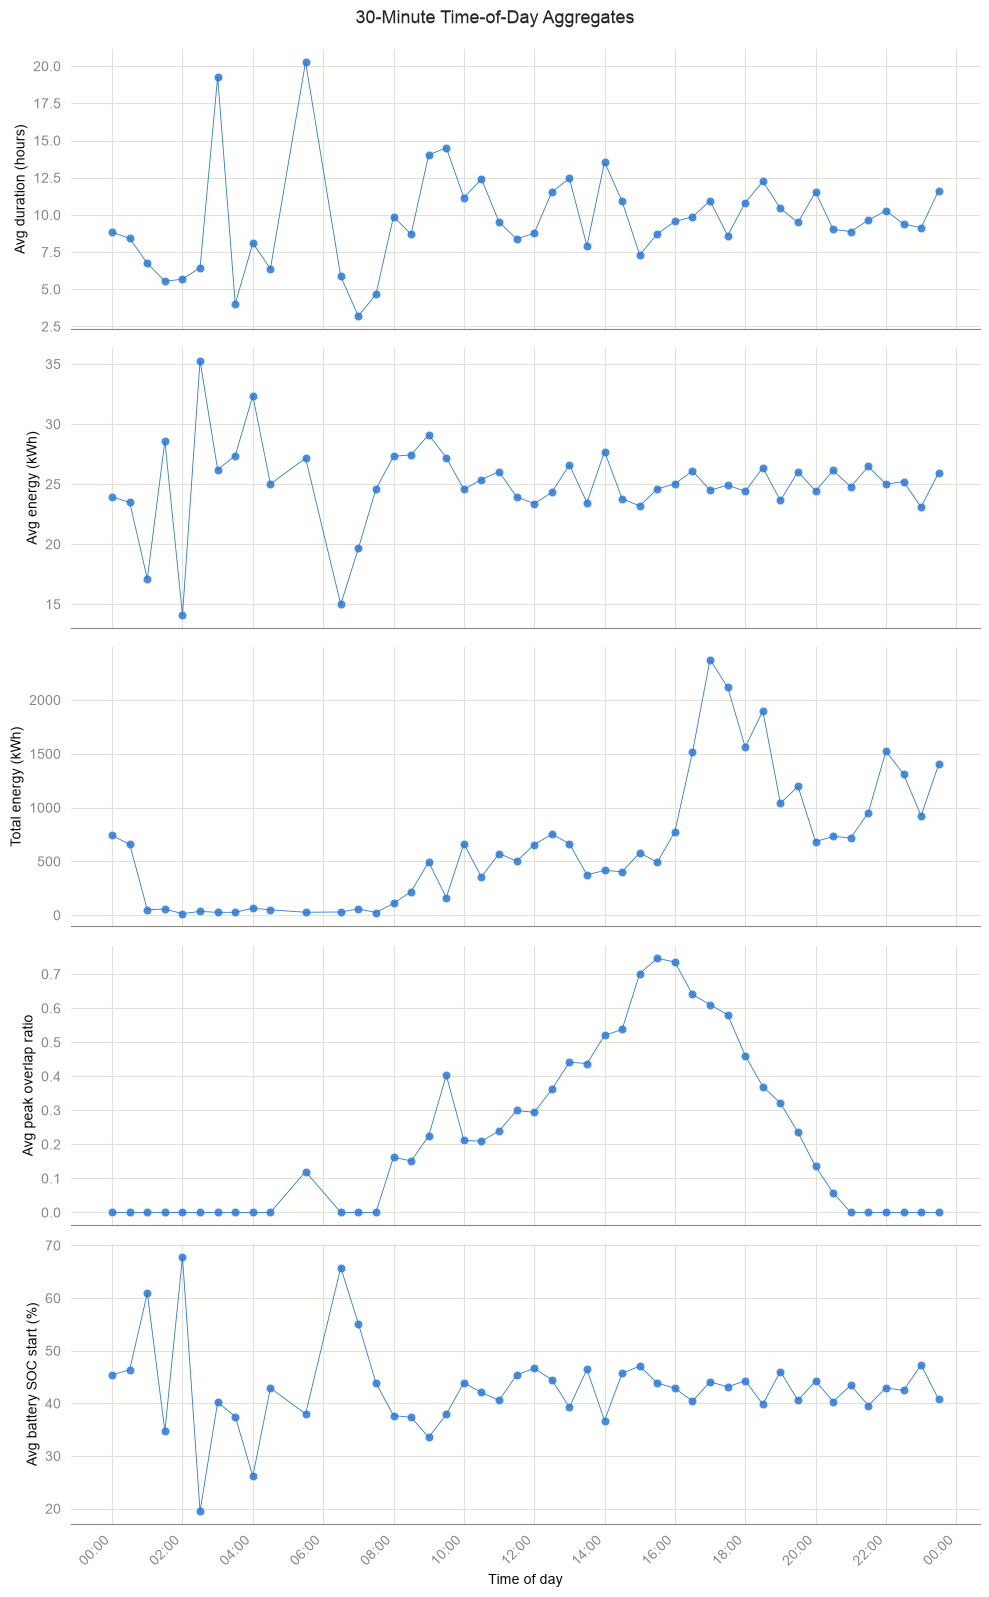

In [11]:
import matplotlib.dates as mdates

# Time-of-day index -> datetime on a dummy day, so matplotlib can treat it as a time axis
x = pd.to_datetime(agg_30min.index.astype(str))

metrics = [
    ("avg_duration_hours", "Avg duration (hours)"),
    ("avg_energy_kwh", "Avg energy (kWh)"),
    ("total_energy_kwh", "Total energy (kWh)"),
    ("avg_peak_overlap_ratio", "Avg peak overlap ratio"),
    ("avg_battery_soc_start", "Avg battery SOC start (%)"),
]

MARK_COLOR = "#2a78d6"
GRID_COLOR = "#e1e0d9"
MUTED = "#898781"

fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 16), sharex=True)

for ax, (col, label) in zip(axes, metrics):
    ax.scatter(x, agg_30min[col], s=40, color=MARK_COLOR, alpha=0.85,
               edgecolor="white", linewidth=0.6, zorder=3)
    ax.plot(x, agg_30min[col], color=MARK_COLOR,linewidth=0.6, zorder=3)
    ax.set_ylabel(label, color="#0b0b0b")
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")
axes[-1].set_xlabel("Time of day", color="#0b0b0b")

fig.suptitle("30-Minute Time-of-Day Aggregates", y=0.995, fontsize=13)
fig.tight_layout()
fig.savefig("reports/graphs/01_time_of_day_aggregates.png", dpi=300, bbox_inches="tight")
plt.show()

## Day of week and month

Derives calendar features from `start_time_datetime_conv` for later grouping/seasonality analysis.

In [12]:
df_sessions["day_of_week"] = df_sessions["start_time_datetime_conv"].dt.day_name()
df_sessions["month"] = df_sessions["start_time_datetime_conv"].dt.month_name()

df_sessions[["start_time_datetime_conv", "day_of_week", "month"]].head()

,start_time_datetime_conv,day_of_week,month
0,2025-08-14 10:38:00,Thursday,August
1,2025-07-21 18:49:00,Monday,July
2,2025-01-19 17:42:00,Sunday,January
3,2025-12-01 18:57:00,Monday,December
4,2025-06-16 17:19:00,Monday,June


### Total energy usage by month and by day of week

Bar charts of summed `energy_kwh`, with months in calendar order (January–December)
and days in weekday order (Monday–Sunday) rather than alphabetical or first-seen order.

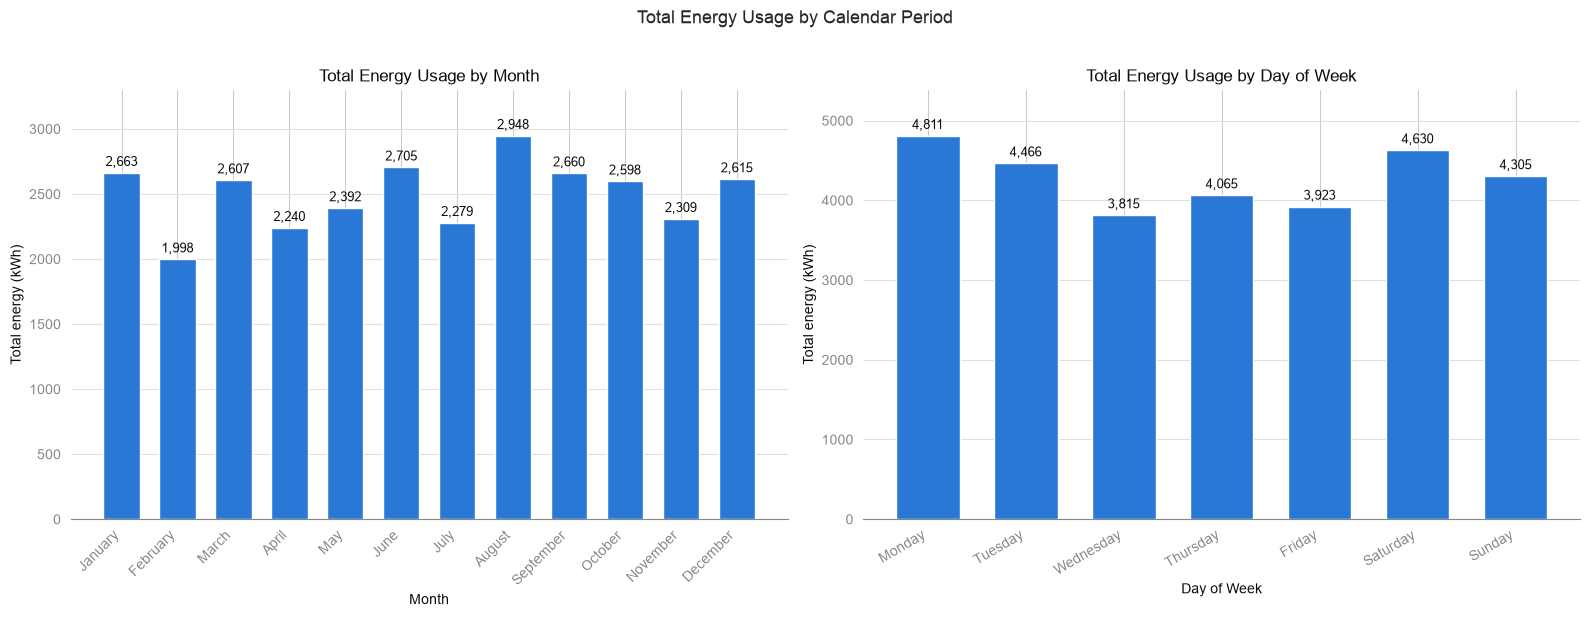

In [13]:
MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday",
]

energy_by_month = (
    df_sessions.groupby("month")["energy_kwh"].sum().reindex(MONTH_ORDER, fill_value=0)
)
energy_by_day = (
    df_sessions.groupby("day_of_week")["energy_kwh"].sum().reindex(DAY_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

panels = (
    (axes[0], energy_by_month, "Total Energy Usage by Month", "Month", 45),
    (axes[1], energy_by_day, "Total Energy Usage by Day of Week", "Day of Week", 30),
)

for ax, data, title, xlabel, rotation in panels:
    bars = ax.bar(data.index, data.values, color=MARK_COLOR, width=0.65, zorder=3)
    ax.bar_label(
        bars,
        labels=[f"{v:,.0f}" for v in data.values],
        padding=3, fontsize=9, color="#0b0b0b",
    )

    ax.set_title(title, fontsize=12, color="#0b0b0b")
    ax.set_xlabel(xlabel, color="#0b0b0b")
    ax.set_ylabel("Total energy (kWh)", color="#0b0b0b")
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)
    plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right")
    ax.margins(y=0.12)  # headroom so data labels don't clip the top

fig.suptitle("Total Energy Usage by Calendar Period", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig("reports/graphs/02_energy_usage_by_month_and_day.png", dpi=300, bbox_inches="tight")
plt.show()

### Consumption Exploration

BC-wide monthly consumption, for context; see **Data Loading & Documentation** above for source and column details. Used qualitatively here; the value column isn't cleaned to numeric since it isn't used quantitatively downstream (known issue #4 above).

In [14]:
df_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Geography                48 non-null     str  
 1   Reference period         48 non-null     str  
 2   3 - value measure (MWh)  48 non-null     str  
dtypes: str(3)
memory usage: 3.3 KB


In [15]:
df_consumption.describe()

,Geography,Reference period,3 - value measure (MWh)
count,48,48,48
unique,1,48,48
top,British Columbia,2022-06-01 00:00:00,"4,261,299"
freq,48,1,1


In [16]:
df_consumption.head()

,Geography,Reference period,3 - value measure (MWh)
0,British Columbia,2022-06-01 00:00:00,"4,261,299"
1,British Columbia,2022-07-01 00:00:00,"4,415,055"
2,British Columbia,2022-08-01 00:00:00,"4,870,866"
3,British Columbia,2022-09-01 00:00:00,"4,465,966"
4,British Columbia,2022-10-01 00:00:00,"4,880,649"


### Authority Load Exploration

Hourly BC Hydro balancing-authority load for 2025; see **Data Loading & Documentation** above for source, column definitions, and the `HE == "2*"` daylight-saving quirk.

In [17]:
df_authority_load.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date               8760 non-null   str  
 1   HE                 8760 non-null   str  
 2   Control Area Load  8760 non-null   int64
dtypes: int64(1), str(2)
memory usage: 304.9 KB


In [18]:
df_authority_load.describe()

,Control Area Load
count,8760.000000
mean,7682.072831
std,1172.922864
min,5359.000000
25%,6896.750000
50%,7570.000000
75%,8475.000000
max,11359.000000


In [19]:
df_authority_load.head()

,Date,HE,Control Area Load
0,01/01/2025,1,7942
1,01/01/2025,2,7819
2,01/01/2025,3,7710
3,01/01/2025,4,7637
4,01/01/2025,5,7670


### Mean and median control area load by hour ending

Grouped bar chart comparing the mean and median `Control Area Load` for each
`HE` bucket (1–24), to see how the two central-tendency measures diverge across
the daily load curve.

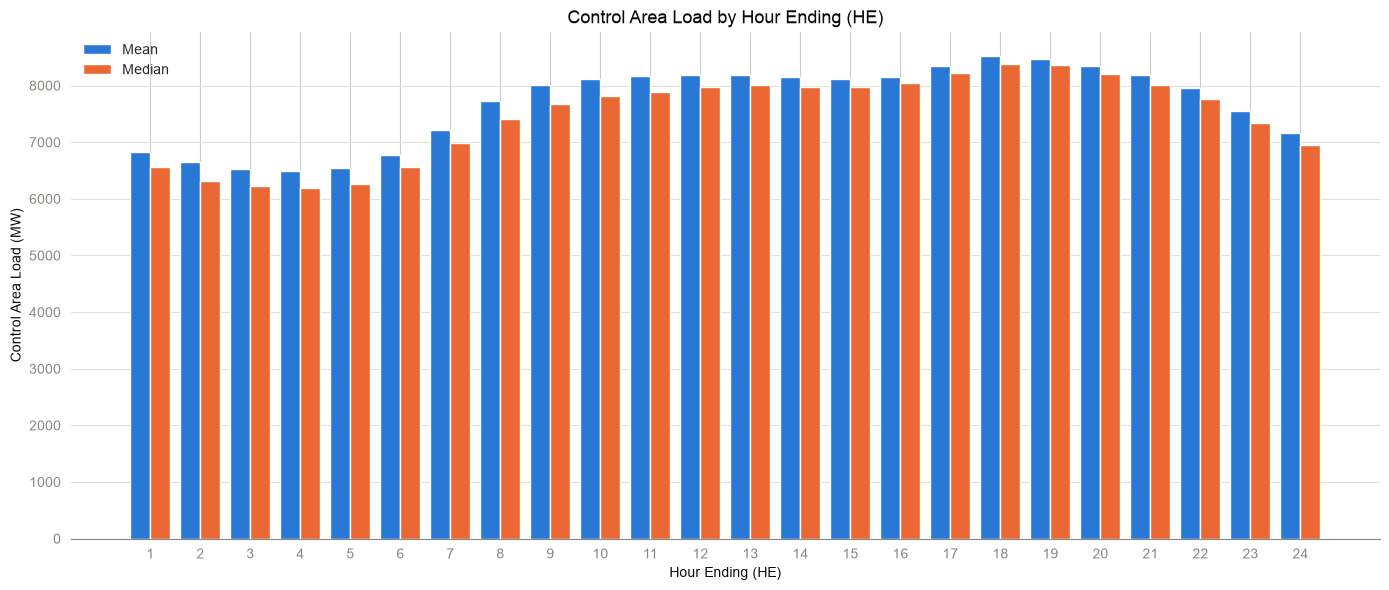

In [20]:
HE_ORDER = [str(h) for h in range(1, 25)]

he_stats = (
    df_authority_load.groupby("HE")["Control Area Load"]
    .agg(["mean", "median"])
    .reindex(HE_ORDER)
)

MEAN_COLOR = MARK_COLOR
MEDIAN_COLOR = "#eb6834"

x = np.arange(len(he_stats))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width / 2, he_stats["mean"], width, label="Mean",
       color=MEAN_COLOR, zorder=3)
ax.bar(x + width / 2, he_stats["median"], width, label="Median",
       color=MEDIAN_COLOR, zorder=3)

ax.set_title("Control Area Load by Hour Ending (HE)", fontsize=13, color="#0b0b0b")
ax.set_xlabel("Hour Ending (HE)", color="#0b0b0b")
ax.set_ylabel("Control Area Load (MW)", color="#0b0b0b")
ax.set_xticks(x)
ax.set_xticklabels(he_stats.index)
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
fig.savefig("reports/graphs/03_control_area_load_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()

# Problem 1: Evaluating Policy Options A, B, and C

**Technique selection & justification:** targeted descriptive analytics: pulling the specific slice of evidence each option's mechanism depends on (surcharge-window exposure for A, dwelling-density proxy for B, behavioral heterogeneity for C) rather than a single blanket EDA pass, since each option lives or dies on different evidence. Findings and interpretation are inline with each option below, closing with a side-by-side summary that stops short of a recommendation per the client Q&A, the equity read on Option A is a stated assumption, not a data-derived finding (see Assumptions Log).

## Policy Options Evaluation (Options A / B / C)

The client has proposed three candidate policy responses to rising EV charging demand on the BC Hydro grid. Restated briefly from client conversations:

- **Option A** -- Introduce a province-wide mandatory peak tariff penalty on all home power use between 4:00 PM and 9:00 PM.
- **Option B** -- Launch a large-scale capital project to replace and upgrade neighborhood transformers across Metro Vancouver.
- **Option C** -- Use data science to cluster EV drivers into distinct charging habit groups, enabling targeted off-peak incentives that encourage drivers to shift their charging times.

This section pulls whatever evidence the `sessions`, `consumption`, and `authority_load` datasets can actually speak to for each option. The goal here is descriptive, not prescriptive: findings are presented side by side, without ranking the options or recommending a winner. Rather, that call sits with the client, and depends on cost, equity, and implementation factors this dataset alone can't settle.

### Option A -- Province-Wide 4–9 PM Peak Tariff Penalty

Since Option A would apply a surcharge to all home power use in the 4–9 PM window, the most direct evidence available is how much EV charging load actually falls inside that window today. `peak_overlap_ratio` is (per the sessions data dictionary) the fraction of a session's duration that overlaps 4–9 PM which is spot-checking it against a manual overlap calculation from `start_time`/`duration_hours` confirms it tracks the window closely (Pearson r ≈ 0.98), so it's a reliable basis for this evidence.

count    1200.000
mean        0.309
std         0.303
min         0.000
25%         0.000
50%         0.285
75%         0.470
max         1.000
Name: peak_overlap_ratio, dtype: float64

Overall share of total session energy inside the 4-9 PM window: 30.0%

                 total_energy_kwh  energy_in_window_kwh  pct_energy_in_window
housing_type                                                                 
Condo/Apartment           7316.74             2363.6329                  32.3
Single-Family            15039.32             4381.8298                  29.1
Townhouse                 7658.38             2254.7922                  29.4


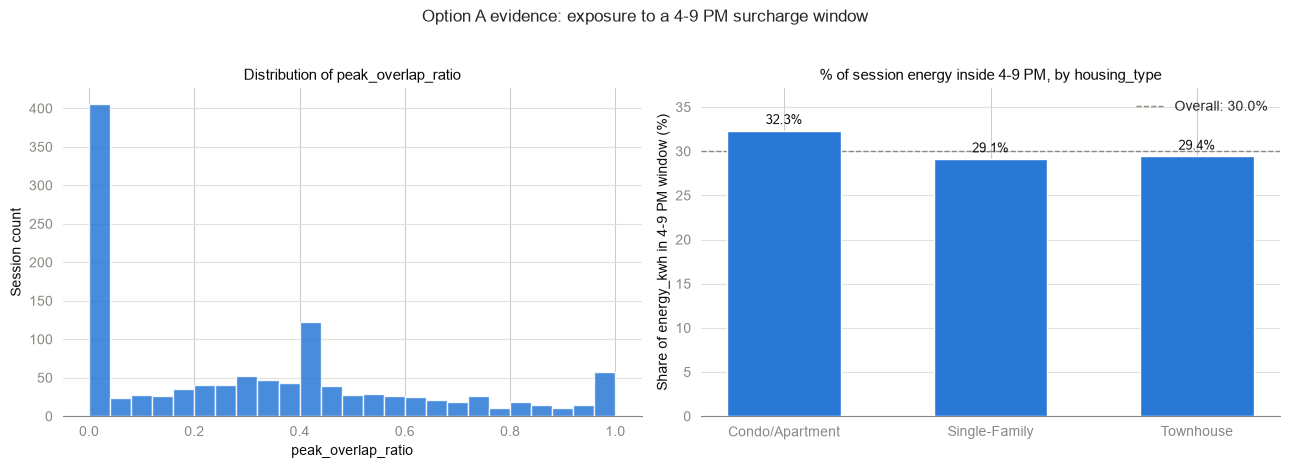

In [21]:
# Distribution of peak_overlap_ratio, plus the share of total session energy
# that falls inside the proposed 4-9 PM surcharge window, by housing_type.
print(df_sessions["peak_overlap_ratio"].describe().round(3))

energy_in_window = df_sessions["energy_kwh"] * df_sessions["peak_overlap_ratio"]

by_housing_a = pd.DataFrame({
    "total_energy_kwh": df_sessions.groupby("housing_type")["energy_kwh"].sum(),
    "energy_in_window_kwh": energy_in_window.groupby(df_sessions["housing_type"]).sum(),
})
by_housing_a["pct_energy_in_window"] = (
    by_housing_a["energy_in_window_kwh"] / by_housing_a["total_energy_kwh"] * 100
).round(1)

overall_pct_in_window = energy_in_window.sum() / df_sessions["energy_kwh"].sum() * 100
print(f"\nOverall share of total session energy inside the 4-9 PM window: {overall_pct_in_window:.1f}%\n")
print(by_housing_a)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_sessions["peak_overlap_ratio"], bins=25, color=MARK_COLOR, alpha=0.85, zorder=3)
axes[0].set_xlabel("peak_overlap_ratio", color="#0b0b0b")
axes[0].set_ylabel("Session count", color="#0b0b0b")
axes[0].set_title("Distribution of peak_overlap_ratio", fontsize=11, color="#0b0b0b")

bars = axes[1].bar(
    by_housing_a.index, by_housing_a["pct_energy_in_window"], color=MARK_COLOR, width=0.55, zorder=3
)
axes[1].bar_label(
    bars, labels=[f"{v:.1f}%" for v in by_housing_a["pct_energy_in_window"]],
    padding=3, fontsize=9, color="#0b0b0b",
)
axes[1].axhline(
    overall_pct_in_window, color=MUTED, linestyle="--", linewidth=1,
    label=f"Overall: {overall_pct_in_window:.1f}%",
)
axes[1].set_ylabel("Share of energy_kwh in 4-9 PM window (%)", color="#0b0b0b")
axes[1].set_title("% of session energy inside 4-9 PM, by housing_type", fontsize=11, color="#0b0b0b")
axes[1].legend(frameon=False)
axes[1].margins(y=0.15)

for ax in axes:
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)

fig.suptitle("Option A evidence: exposure to a 4-9 PM surcharge window", y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig("reports/graphs/04_option_a_peak_overlap_and_housing.png", dpi=300, bbox_inches="tight")
plt.show()

`peak_overlap_ratio` is right-skewed with a floor at 0 (25th percentile is 0; a quarter of sessions never touch the 4–9 PM window at all) and a median of 0.29. Overall, **~30% of total session energy** is delivered inside the proposed surcharge window. Broken down by `housing_type`, exposure is fairly uniform; Condo/Apartment 32.3%, Townhouse 29.4%, Single-Family 29.1%; so on this dataset there's no housing type that stands out as disproportionately exposed to the surcharge by volume.

> **Note:** The equity concern regarding Option A (that it penalizes low-income households without an EV via a system-wide 4–9 PM surcharge) is a stated assumption from client conversations, not a data-backed finding derived from this dataset. The dataset lacks `income` and `household_EV_ownership` fields to test this hypothesis directly.

### Option B -- Neighborhood Transformer Capital Upgrade (Metro Vancouver)

Option B is a capital infrastructure decision, which ideally would be evaluated against per-transformer or per-feeder load data. **The dataset has no `neighborhood`, `transformer_id`, or other sub-geography field** -- `housing_type` (Single-Family / Townhouse / Condo/Apartment) is the closest available proxy for dwelling density, and `authority_load.csv` only reports load at the whole-of-BC-Hydro-territory level, not by neighborhood. What follows is evidence at the resolution the data actually supports, not a substitute for a real load-flow / transformer capacity study.

                 n_sessions  total_energy_kwh  avg_energy_kwh  \
housing_type                                                    
Condo/Apartment         288            7316.7            25.4   
Single-Family           600           15039.3            25.1   
Townhouse               312            7658.4            24.5   

                 share_of_total_energy_pct  
housing_type                                
Condo/Apartment                       24.4  
Single-Family                         50.1  
Townhouse                             25.5  


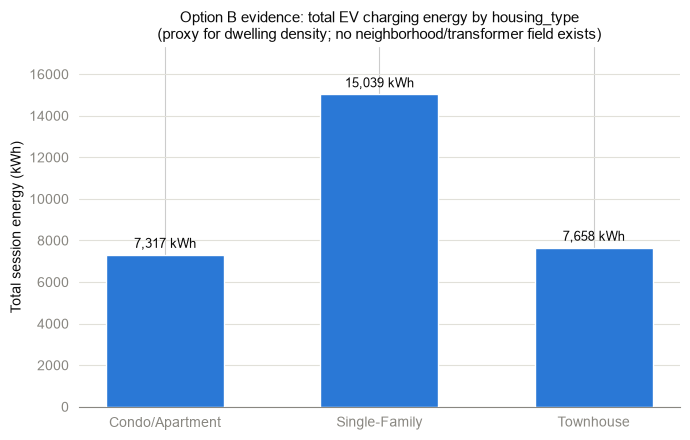

In [22]:
# housing_type is the closest available proxy for neighborhood/dwelling density;
# there is no transformer- or neighborhood-level field to localize demand further.
by_housing_b = df_sessions.groupby("housing_type").agg(
    n_sessions=("session_id", "count"),
    total_energy_kwh=("energy_kwh", "sum"),
    avg_energy_kwh=("energy_kwh", "mean"),
).round(1)
by_housing_b["share_of_total_energy_pct"] = (
    by_housing_b["total_energy_kwh"] / by_housing_b["total_energy_kwh"].sum() * 100
).round(1)
print(by_housing_b)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(by_housing_b.index, by_housing_b["total_energy_kwh"], color=MARK_COLOR, width=0.55, zorder=3)
ax.bar_label(
    bars, labels=[f"{v:,.0f} kWh" for v in by_housing_b["total_energy_kwh"]],
    padding=3, fontsize=9, color="#0b0b0b",
)
ax.set_ylabel("Total session energy (kWh)", color="#0b0b0b")
ax.set_title(
    "Option B evidence: total EV charging energy by housing_type\n"
    "(proxy for dwelling density; no neighborhood/transformer field exists)",
    fontsize=11, color="#0b0b0b",
)
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig("reports/graphs/05_option_b_energy_by_housing_type.png", dpi=300, bbox_inches="tight")
plt.show()

Single-Family sessions account for the largest share of total charging energy (50.1%, n=600), roughly proportional to their 50% share of sessions overall -- Townhouse and Condo/Apartment split the remainder fairly evenly (25.5% / 24.4%). This tells us *which dwelling types* generate the most EV load in aggregate, but not *where*. Without a neighborhood or transformer identifier, the dataset can't say whether that load is concentrated on a handful of already-strained transformers or spread evenly across Metro Vancouver, which is the actual question a capital upgrade decision needs answered.

### Option C -- Cluster-Based Targeted Off-Peak Incentives

Option C's premise is that EV drivers fall into distinguishable charging-habit groups that could each be nudged off-peak differently. Before running the full clustering pipeline (below, in **Preliminary Clustering** and **Clustering**), a quick look at how much session-level behaviour actually varies is useful evidence for whether segmentation is worth doing at all.

       duration_hours  peak_overlap_ratio  battery_soc_start
count         1200.00             1200.00            1200.00
mean            10.13                0.31              42.90
std              8.94                0.30              18.39
min              1.60                0.00              10.00
25%              4.63                0.00              26.90
50%              6.73                0.29              43.05
75%             11.76                0.47              58.60
max             67.65                1.00              74.90


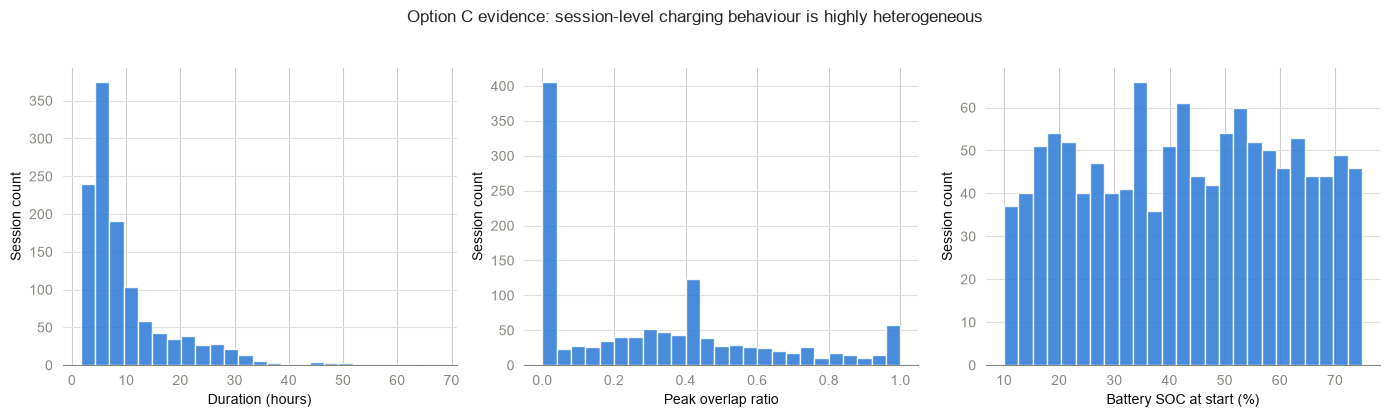

In [23]:
# Quick heterogeneity check: how much does session-level behaviour vary before
# we attempt to formally segment it? (Full segmentation happens in the
# Preliminary Clustering / Clustering sections below.)
print(df_sessions[["duration_hours", "peak_overlap_ratio", "battery_soc_start"]].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(
    axes,
    ["duration_hours", "peak_overlap_ratio", "battery_soc_start"],
    ["Duration (hours)", "Peak overlap ratio", "Battery SOC at start (%)"],
):
    ax.hist(df_sessions[col], bins=25, color=MARK_COLOR, alpha=0.85, zorder=3)
    ax.set_xlabel(label, color="#0b0b0b")
    ax.set_ylabel("Session count", color="#0b0b0b")
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)

fig.suptitle("Option C evidence: session-level charging behaviour is highly heterogeneous", y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig("reports/graphs/06_option_c_session_heterogeneity.png", dpi=300, bbox_inches="tight")
plt.show()

None of these three measures clusters tightly around a single "typical" session; `duration_hours` is bimodal (short Level-2 top-ups vs. long overnight Level-1 sessions), `peak_overlap_ratio` spans the full 0–1 range with a spike at 0, and `battery_soc_start` is fairly uniform across its range. That spread is consistent with there being real, separable charging-habit groups to target: the **Preliminary Clustering** and **Clustering** sections below make this concrete, identifying k=4 K-Means archetypes (see the write-up there), including one high-peak-overlap group of ~429 sessions that would be a natural first target for an off-peak incentive.

### Summary -- side by side, no ranking

| Option | Mechanism | Data available | What the data shows |
|---|---|---|---|
| **A** -- Peak tariff (4–9 PM) | System-wide surcharge on home power use, 4–9 PM | `peak_overlap_ratio`, `energy_kwh` × `housing_type` | ~30% of total session energy falls in the surcharge window; exposure is fairly uniform across housing types (29–32%) |
| **B** -- Transformer upgrade | Capital investment in neighborhood transformers (Metro Vancouver) | `housing_type` as a density proxy, `energy_kwh` (no neighborhood/transformer field) | Single-Family sessions carry the largest energy share (~50%), but the dataset can't localize where transformer stress actually concentrates |
| **C** -- Clustering-based incentives | Segment drivers by charging habit, target off-peak incentives | Full session feature set (duration, timing, charger level, peak overlap) | Session behaviour is highly heterogeneous; formal clustering below finds distinguishable archetypes, including a large high-peak-overlap group |

Each option is evaluated only as far as the available fields allow. Option A has the most direct support, Option B is constrained by missing geographic granularity, and Option C's case is made concrete later in this notebook. No ranking or recommendation is intended here; that is a client decision informed by cost, equity, and delivery considerations beyond this dataset.

# Problem 2: Unsupervised Clustering of Charging Sessions

**Technique selection & justification:** K-Means and DBSCAN, compared head-to-head per the client's request (see `CONTEXT.md` Q&A) rather than picking one upfront. **Modeling** proceeds in three stages below: feature engineering, K-Means (elbow + silhouette to pick k), and DBSCAN (k-distance plot to pick eps). **Evaluation & interpretation** throughout uses Silhouette Score, cluster size balance, and business interpretability, per the client's stated bar for a "good" result, closing with a head-to-head write-up of what each algorithm actually finds.

## Preliminary Clustering

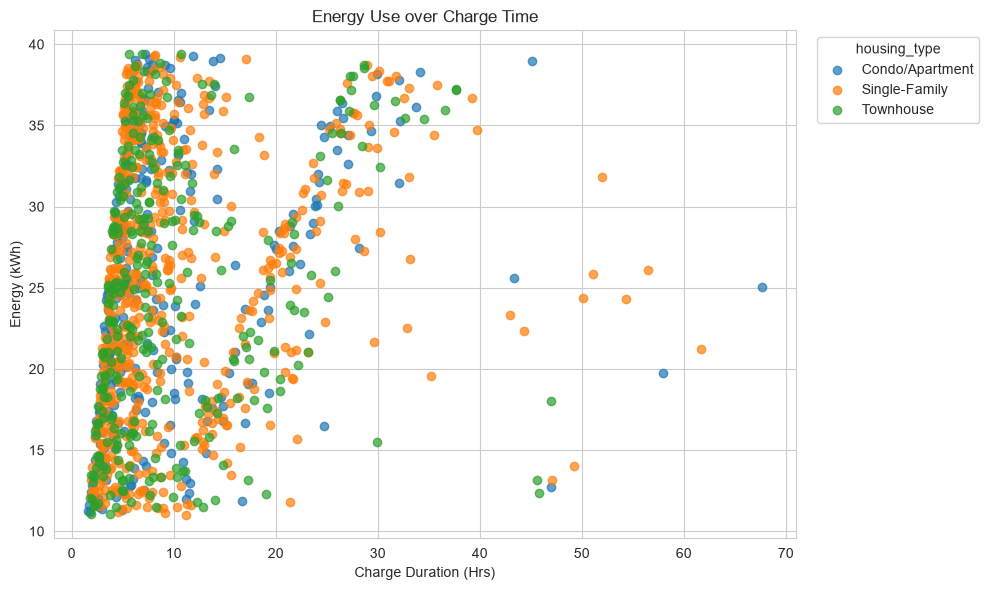

In [24]:
# create scatter plot of energy_kwh vs duration_hours
# group data by housing_type and color each group differently
# add labels, legend, and show plot

plt.figure(figsize=(10, 6))
for area, group in df_sessions.groupby("housing_type"):
    duration = group["duration_hours"]
    energy = group["energy_kwh"]
    plt.scatter(duration, energy, label=area, alpha=0.7)

plt.xlabel("Charge Duration (Hrs)")
plt.ylabel("Energy (kWh)")
plt.title("Energy Use over Charge Time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="housing_type")
plt.tight_layout()
plt.savefig("reports/graphs/07_energy_vs_duration_by_housing.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Engineering for Clustering

Builds a numeric feature matrix from `housing_type`, `charger_level`, `start_time`, `duration_hours`, `energy_kwh`, `peak_overlap_ratio`, `season`, and `battery_soc_start` so it can feed the PCA/t-SNE/UMAP and clustering steps below.

- `charger_level` is parsed into its rated kW (`charger_power_kw`): a more informative numeric signal than the label itself.
- `start_time` is cyclically encoded as `start_hour_sin`/`start_hour_cos` so 23:00 and 00:00 land next to each other rather than at opposite ends of a linear scale, plus an `is_weekend` flag.
- `housing_type` and `season` are nominal, so they're one-hot encoded.
- Continuous fields are standardized afterward so no single scale dominates distance-based clustering.

In [25]:
FEATURE_COLUMNS = [
    "housing_type", "charger_level", "start_time", "duration_hours",
    "energy_kwh", "peak_overlap_ratio", "season", "battery_soc_start",
]

df_features = df_sessions[FEATURE_COLUMNS].copy()

# Charger power (kW) parsed out of the label, e.g. "Level 2 (7.2kW)" -> 7.2
df_features["charger_power_kw"] = (
    df_features["charger_level"].str.extract(r"\(([\d.]+)kW\)").astype(float)
)

# Average delivery rate (kWh per hour plugged in) -- distinguishes a session that
# charged quickly for its duration from one that sat mostly idle.
df_features["energy_to_duration_ratio"] = (
    df_features["energy_kwh"] / df_features["duration_hours"]
)

# Cyclical encoding of time-of-day so hours near midnight stay close together, plus a weekend flag
start_dt = pd.to_datetime(df_features["start_time"])
hour_frac = start_dt.dt.hour + start_dt.dt.minute / 60
df_features["start_hour_sin"] = np.sin(2 * np.pi * hour_frac / 24)
df_features["start_hour_cos"] = np.cos(2 * np.pi * hour_frac / 24)
df_features["is_weekend"] = start_dt.dt.dayofweek.isin([5, 6]).astype(int)

# One-hot encode the nominal categoricals
df_features = pd.get_dummies(
    df_features, columns=["housing_type", "season"], prefix=["housing", "season"], dtype=int
)

# Drop source columns now that they've been encoded
df_features = df_features.drop(columns=["charger_level", "start_time"])

df_features.head()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start,charger_power_kw,energy_to_duration_ratio,start_hour_sin,start_hour_cos,is_weekend,housing_Condo/Apartment,housing_Single-Family,housing_Townhouse,season_Fall,season_Spring,season_Summer,season_Winter
0,12.51,17.30,0.42,60.5,1.4,1.382894,0.350207,-0.936672,0,0,0,1,0,0,0,1
1,9.99,35.35,0.23,19.3,7.2,3.538539,-0.977231,0.212178,0,1,0,0,0,1,0,0
2,7.72,35.62,0.45,18.7,7.2,4.613990,-0.996917,-0.078459,1,0,1,0,0,1,0,0
3,49.23,14.02,0.19,68.0,7.2,0.284786,-0.969231,0.246153,0,0,1,0,0,0,0,1
4,3.21,19.63,1.00,55.2,7.2,6.115265,-0.984041,-0.177944,0,0,0,1,1,0,0,0


### Redundancy check: `energy_kwh` vs. `battery_soc_start`

The correlation matrix below shows `energy_kwh` and `battery_soc_start` at a suspicious **-1.00**. A perfect linear correlation between "energy delivered" and "battery level at plug-in" is exactly what you'd expect from a synthetic data generator that derives one directly from the other (e.g. `energy_kwh ≈ battery_capacity × (1 - battery_soc_start / 100)`), rather than a genuine empirical relationship. The scatter plot confirms it: every point sits on a single straight line, with no scatter/noise around it.

Since the two columns carry the same information, leaving both in `X` would double-count that signal in any distance-based clustering. `energy_kwh` is dropped from `CONTINUOUS_COLUMNS` below so it no longer contributes to `X`, but it's kept in `df_features`/`profile_cols` so cluster profiles can still be described in familiar kWh terms.

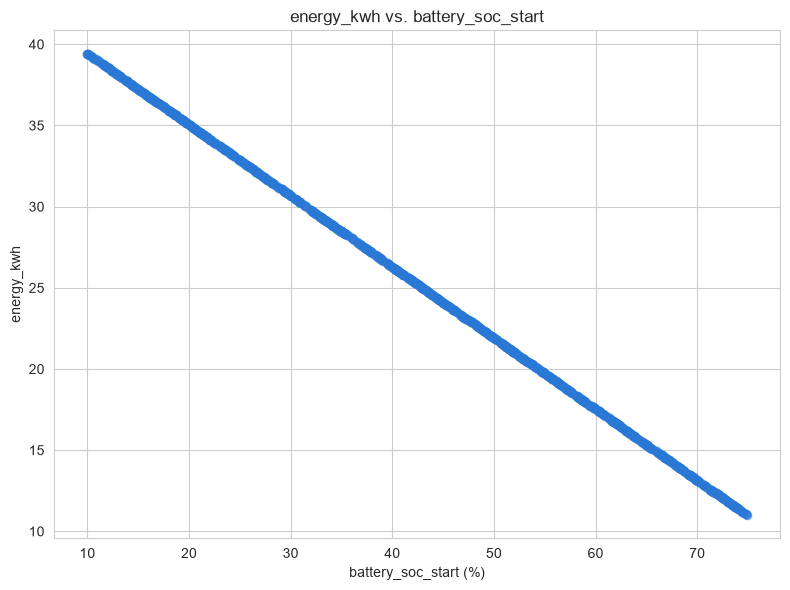

Correlation: -1.0000


In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(df_features["battery_soc_start"], df_features["energy_kwh"], alpha=0.5, color=MARK_COLOR)
plt.xlabel("battery_soc_start (%)")
plt.ylabel("energy_kwh")
plt.title("energy_kwh vs. battery_soc_start")
plt.tight_layout()
plt.savefig("reports/graphs/08_energy_vs_battery_soc_start.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Correlation: {df_features['energy_kwh'].corr(df_features['battery_soc_start']):.4f}")

In [27]:
CONTINUOUS_COLUMNS = [
    "duration_hours", "peak_overlap_ratio", "battery_soc_start",
    "charger_power_kw", "start_hour_sin", "start_hour_cos", "energy_to_duration_ratio",
]

scaler = StandardScaler()
df_features_scaled = df_features.copy()
df_features_scaled[CONTINUOUS_COLUMNS] = scaler.fit_transform(df_features[CONTINUOUS_COLUMNS])

# X is built explicitly from CONTINUOUS_COLUMNS plus the binary/dummy columns --
# NOT from every column in df_features_scaled -- so that `energy_kwh` (redundant
# with battery_soc_start, see the check above) is excluded from clustering
# entirely rather than sneaking back in unscaled.
DUMMY_COLUMNS = [c for c in df_features.columns if c.startswith("housing_") or c.startswith("season_")]
MODEL_COLUMNS = CONTINUOUS_COLUMNS + ["is_weekend"] + DUMMY_COLUMNS

X = df_features_scaled[MODEL_COLUMNS].values
df_features_scaled.head()

,duration_hours,energy_kwh,peak_overlap_ratio,battery_soc_start,charger_power_kw,energy_to_duration_ratio,start_hour_sin,start_hour_cos,is_weekend,housing_Condo/Apartment,housing_Single-Family,housing_Townhouse,season_Fall,season_Spring,season_Summer,season_Winter
0,0.266525,17.30,0.367523,0.957395,-2.059168,-1.186731,1.756537,-1.472097,0,0,0,1,0,0,0,1
1,-0.015603,35.35,-0.258796,-1.284405,0.485633,-0.099057,-0.909316,0.200986,0,1,0,0,0,1,0,0
2,-0.269741,35.62,0.466416,-1.317053,0.485633,0.443583,-0.948851,-0.222272,1,0,1,0,0,1,0,0
3,4.377524,14.02,-0.390653,1.365489,0.485633,-1.740804,-0.893249,0.250465,0,0,1,0,0,0,0,1
4,-0.774660,19.63,2.279446,0.669008,0.485633,1.201082,-0.922991,-0.367152,0,0,0,1,1,0,0,0


### Correlation Matrix

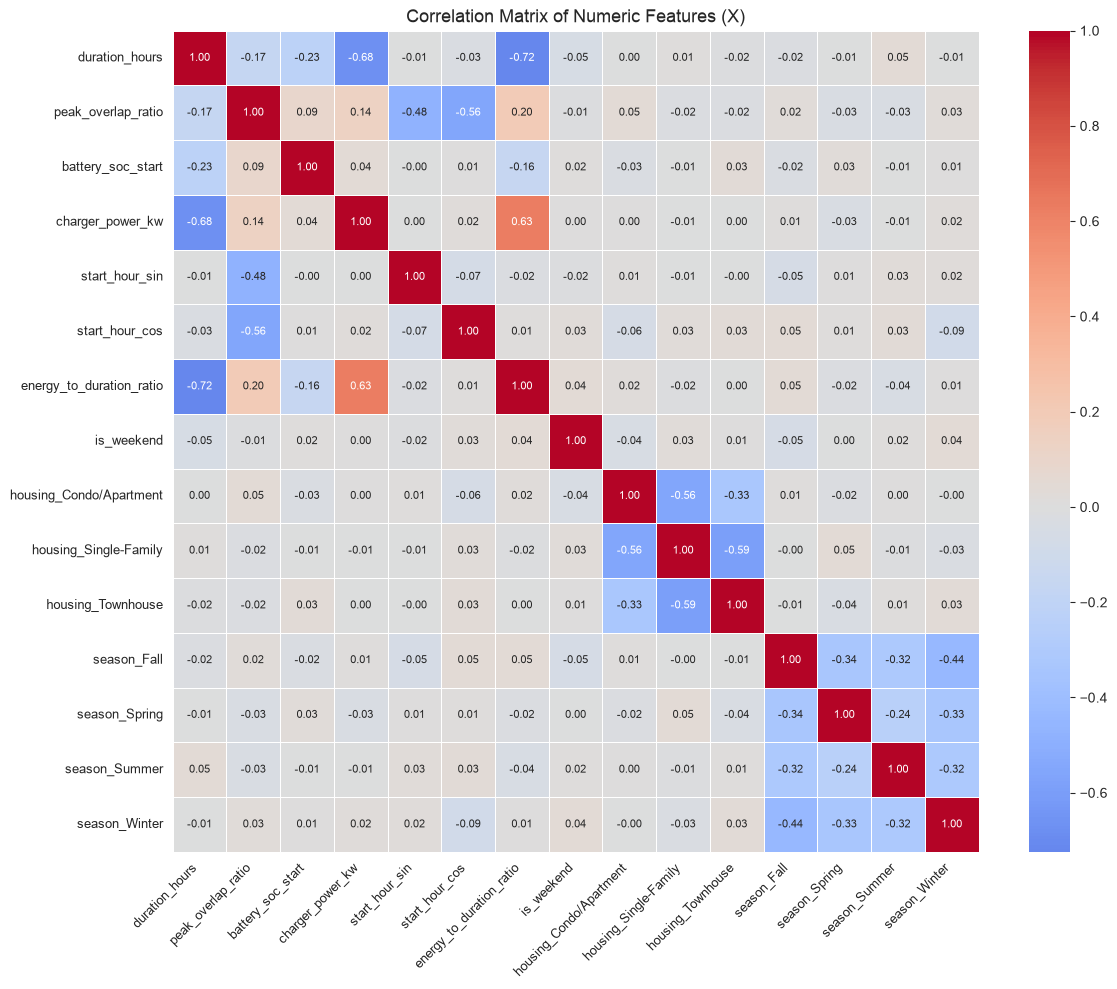

In [28]:
# Correlation matrix of the exact numeric features that go into X
corr = df_features_scaled[MODEL_COLUMNS].corr()

# Plot as heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix of Numeric Features (X)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
fig.savefig("reports/graphs/09_feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Clustering

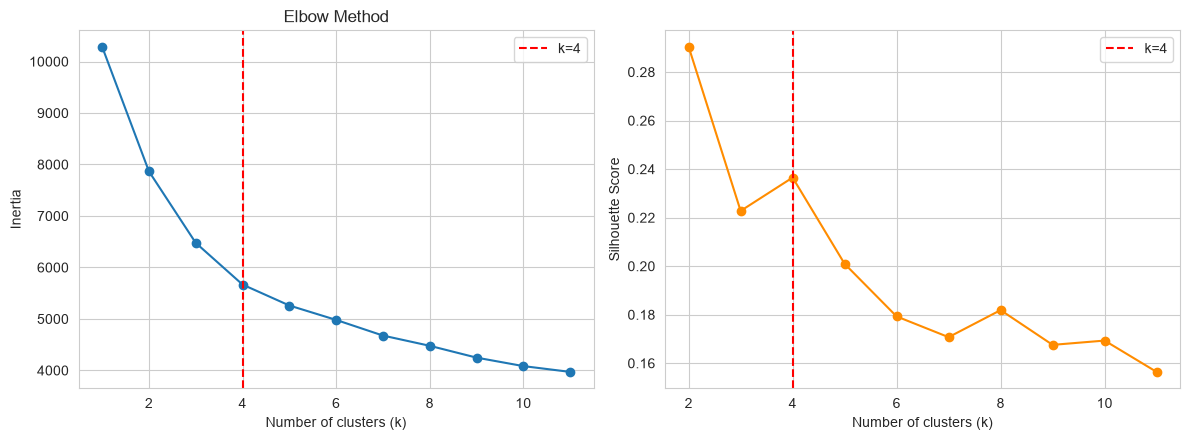

In [29]:
k_max = 12

inertias = []
for k in range(1, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

silhouette_scores = {}
for k in range(2, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, km_labels)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(range(1, k_max), inertias, marker="o")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")
ax[0].axvline(x=4, color="red", linestyle="--", label="k=4")
ax[0].legend()

ax[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].axvline(x=4, color="red", linestyle="--", label="k=4")
ax[1].legend()

plt.tight_layout()
fig.savefig("reports/graphs/10_kmeans_elbow_and_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

**Shift from the original k=5 choice:** dropping `energy_kwh` and adding `energy_to_duration_ratio` changes the silhouette landscape enough to change the pick. Scores are now: k=2 -> 0.290, k=3 -> 0.223, **k=4 -> 0.237**, k=5 -> 0.201, k=6 -> 0.179, k=7 -> 0.171, k=8 -> 0.182 (roughly flat/low from there). **k=5 is no longer a local maximum**. Now, it sits on the declining slope right after k=4's local peak, so the reasoning that originally justified k=5 (a local silhouette maximum, more interpretable than 7–8) now points to **k=4** instead. The global maximum is k=2 (0.290), but as the DBSCAN section below confirms, that split just recovers the binary Level 1 vs. Level 2 charger split, which is too coarse to be a useful behavioural segmentation. k=4 is the best local peak that still yields more than a single hardware-driven split, so that's the choice going forward.

#### Plotting KMeans with Optimal K

Here, I fit KMeans with the chosen k=4 and inspect what each cluster actually represents.

In [30]:
kmeans_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df_sessions["KMeans_Cluster"] = kmeans_final.fit_predict(X)
df_features["KMeans_Cluster"] = df_sessions["KMeans_Cluster"]

df_sessions["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    180
1    429
2    343
3    248
Name: count, dtype: int64

#### Cluster Profiles

A quick sanity check on what each cluster actually represents: mean charging behaviour per cluster, plus how each cluster breaks down by `housing_type` and `season`.

In [31]:
profile_cols = [
    "duration_hours", "energy_kwh", "energy_to_duration_ratio",
    "peak_overlap_ratio", "battery_soc_start", "charger_power_kw",
]

cluster_profile = df_features.groupby("KMeans_Cluster")[profile_cols].mean().round(2)
cluster_profile["n"] = df_sessions["KMeans_Cluster"].value_counts().sort_index()
cluster_profile

,duration_hours,energy_kwh,energy_to_duration_ratio,peak_overlap_ratio,battery_soc_start,charger_power_kw,n
KMeans_Cluster,,,,,,,
0,6.84,24.88,4.32,0.25,43.22,7.20,180
1,6.13,24.74,4.57,0.61,43.52,7.20,429
2,6.81,25.22,4.27,0.03,42.44,7.20,343
3,24.04,25.30,1.12,0.22,42.26,1.84,248


In [32]:
# Do housing_type / season line up with the clusters, or are they irrelevant to how sessions group?
display(pd.crosstab(df_sessions["KMeans_Cluster"], df_sessions["housing_type"], normalize="index").round(2))
display(pd.crosstab(df_sessions["KMeans_Cluster"], df_sessions["season"], normalize="index").round(2))

housing_type,Condo/Apartment,Single-Family,Townhouse
KMeans_Cluster,,,
0,0.28,0.48,0.24
1,0.26,0.47,0.28
2,0.20,0.54,0.26
3,0.23,0.51,0.25


season,Fall,Spring,Summer,Winter
KMeans_Cluster,,,,
0,0.24,0.21,0.18,0.38
1,0.33,0.18,0.17,0.32
2,0.32,0.22,0.20,0.26
3,0.29,0.23,0.20,0.28


**How the archetypes shifted:** removing `energy_kwh` from `X` and adding `energy_to_duration_ratio` changed more than just the chosen k -- it changed what actually separates the clusters. In the original 5-cluster solution, `battery_soc_start` was a defining axis (a "fast top-up from a near-empty battery" cluster at ~24% SOC vs. "already-charged" clusters at ~55%+ SOC). In the new 4-cluster solution, `battery_soc_start` barely varies across clusters (42–44% everywhere) -- it's no longer doing any separating work. That makes sense: `battery_soc_start` was only differentiating clusters *through* its near-perfect (anti-)correlation with `energy_kwh`, and now that `energy_kwh` is out of `X`, the dominant axis among Level-2 sessions has shifted to **`peak_overlap_ratio`** (timing relative to the 4–9 PM window) instead:

- **Cluster 0** (n=180) -- Level 2 (7.2kW), duration ~6.84h, moderate peak overlap (~0.25, near the dataset average) -- **typical Level-2 charging, mild peak exposure**.
- **Cluster 1** (n=429) -- Level 2, shortest duration (~6.13h), high peak overlap (~0.61) -- **peak-hour Level-2 charging**. This is now the single largest cluster, and the most directly exposed to a 4–9 PM surcharge (Option A) or a targeted off-peak incentive (Option C).
- **Cluster 2** (n=343) -- Level 2, duration ~6.81h, near-zero peak overlap (~0.03) -- **off-peak Level-2 charging, minimal grid-peak impact**.
- **Cluster 3** (n=248) -- 92% Level 1 (1.4kW), long duration (~24.0h), low delivery rate (~1.1 kWh/h vs. ~4.3–4.6 kWh/h for the Level-2 clusters) -- **overnight Level-1 charging**.

`housing_type` and `season` still track the dataset's overall base rates in every cluster (~48–54% Single-Family, ~20–28% Condo/Townhouse; seasons within a similar range of each other) -- as with the original 5-cluster solution, neither feature meaningfully separates the clusters. So the update reinforces the original conclusion (this is a *behavioural*, not demographic, segmentation) while sharpening *which* behaviour actually matters: once the redundant energy signal is removed, charger hardware (Level 1 vs. 2) and timing relative to the grid peak -- not battery state-of-charge at plug-in -- are what distinguish charging sessions.

### PCA Projection to 2D

`X` has 15 dimensions (7 scaled numeric + `is_weekend` + 3 housing dummies + 4 season dummies), too many to plot directly. PCA compresses it to the 2 directions of greatest variance so the clusters can be visualized on a scatter plot.

Explained variance: PC1=28.4%, PC2=19.3%, total=47.7%


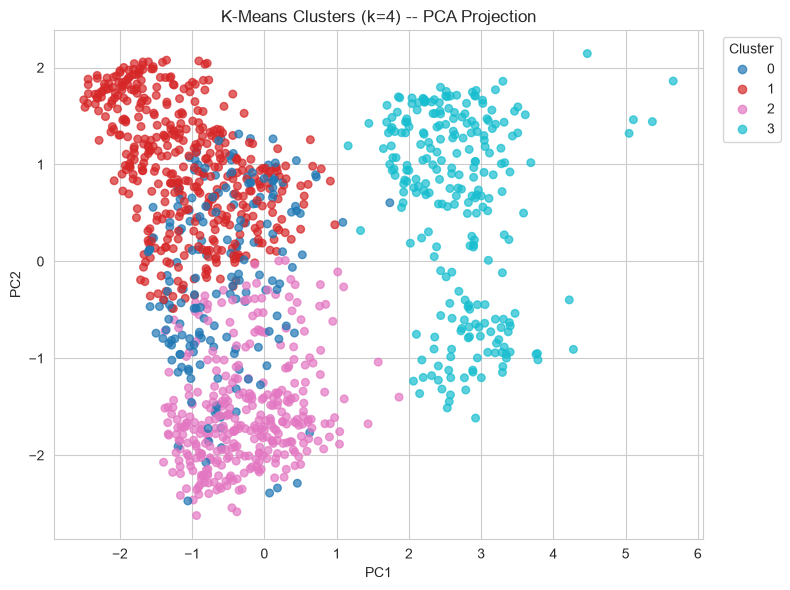

In [33]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, total={pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sessions["KMeans_Cluster"], cmap="tab10", alpha=0.7, s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=4) -- PCA Projection")
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("reports/graphs/11_kmeans_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()

### Evaluating: DBSCAN

For `min_samples` I use 15 (roughly the dimensionality of the 15-column feature matrix `X`) following the common minPts ≈ D+1 rule of thumb for higher-dimensional DBSCAN. `eps` is chosen from the k-distance plot below.

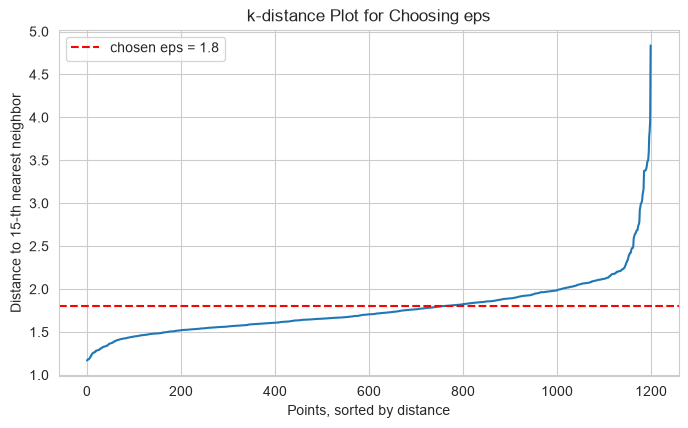

In [34]:
min_samples = 15

neighbours_model = NearestNeighbors(n_neighbors=min_samples)
neighbours_model.fit(X)
distances, _ = neighbours_model.kneighbors(X)

k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_distances)
ax.axhline(1.8, color="red", linestyle="--", label="chosen eps = 1.8")
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel(f"Distance to {min_samples}-th nearest neighbor")
ax.set_title("k-distance Plot for Choosing eps")
ax.legend()
fig.savefig("reports/graphs/12_dbscan_k_distance_plot.png", dpi=300, bbox_inches="tight")
plt.show()

The curve rises gradually rather than showing one sharp knee -- a symptom of the feature matrix containing a strong near-binary split (`charger_power_kw` only takes two values, 1.4 vs 7.2 kW) layered under smoother continuous variation. I swept `eps` from 1.6–2.5 and found the cluster count is stable at 2 across the whole range; the choice mostly trades off noise fraction against cluster purity. I settle on **eps=1.8**, which sits just past the initial knee and keeps noise to a moderate ~12% of rows without over-merging the two dense cores.

In [35]:
dbscan = DBSCAN(eps=1.8, min_samples=min_samples)
df_sessions["DBSCAN_Cluster"] = dbscan.fit_predict(X)
df_features["DBSCAN_Cluster"] = df_sessions["DBSCAN_Cluster"]

n_clusters_dbscan = len(set(df_sessions["DBSCAN_Cluster"])) - (1 if -1 in df_sessions["DBSCAN_Cluster"].values else 0)
n_noise_dbscan = (df_sessions["DBSCAN_Cluster"] == -1).sum()
print(f"Number of clusters: {n_clusters_dbscan} and number of noise points: {n_noise_dbscan} (out of {len(df_sessions)} rows)")

df_sessions.groupby("DBSCAN_Cluster")["charger_level"].value_counts(normalize=True).round(2)

Number of clusters: 2 and number of noise points: 142 (out of 1200 rows)


DBSCAN_Cluster  charger_level  
-1              Level 2 (7.2kW)    0.55
                Level 1 (1.4kW)    0.45
 0              Level 2 (7.2kW)    1.00
 1              Level 1 (1.4kW)    1.00
Name: proportion, dtype: float64

In [36]:
# Quantitative silhouette score for DBSCAN, excluding noise points (label == -1)
dbscan_mask = df_sessions["DBSCAN_Cluster"] != -1
dbscan_silhouette = silhouette_score(
    X[dbscan_mask], df_sessions.loc[dbscan_mask, "DBSCAN_Cluster"]
)
print(f"DBSCAN silhouette (excluding noise): {dbscan_silhouette:.3f}")

DBSCAN silhouette (excluding noise): 0.289


In [37]:
dbscan_profile = df_features.groupby("DBSCAN_Cluster")[profile_cols].mean().round(2)
dbscan_profile["n"] = df_sessions["DBSCAN_Cluster"].value_counts().sort_index()
dbscan_profile

,duration_hours,energy_kwh,energy_to_duration_ratio,peak_overlap_ratio,battery_soc_start,charger_power_kw,n
DBSCAN_Cluster,,,,,,,
-1,19.78,24.65,2.47,0.19,43.74,4.59,142
0,6.49,24.96,4.41,0.34,43.02,7.20,893
1,21.55,25.61,1.19,0.21,41.54,1.40,165


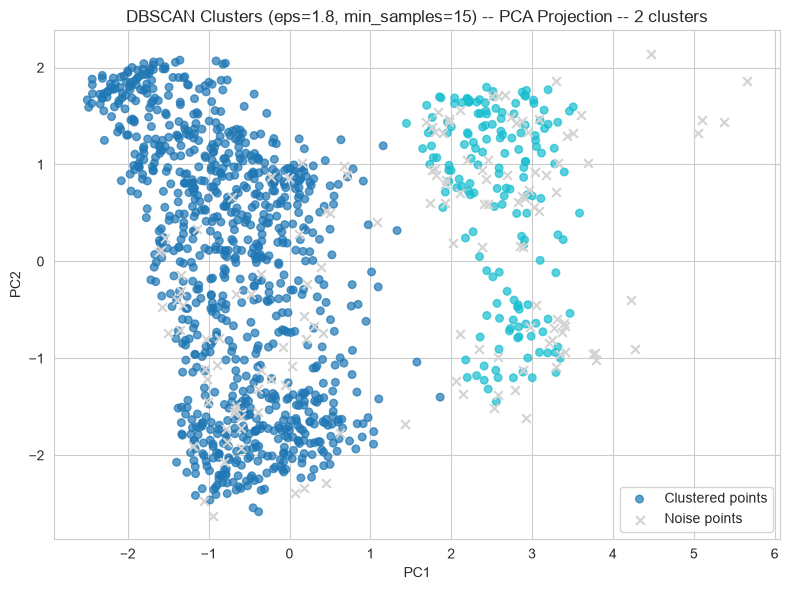

In [38]:
noise_mask = df_sessions["DBSCAN_Cluster"] == -1

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
    c=df_sessions.loc[~noise_mask, "DBSCAN_Cluster"], cmap="tab10", alpha=0.7, s=30, label="Clustered points",
)
plt.scatter(
    X_pca[noise_mask, 0], X_pca[noise_mask, 1],
    c="lightgrey", marker="x", s=40, label="Noise points",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN Clusters (eps=1.8, min_samples={min_samples}) -- PCA Projection -- {n_clusters_dbscan} clusters")
plt.legend()
plt.tight_layout()
plt.savefig("reports/graphs/13_dbscan_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()

### Write-up -- KMeans vs. DBSCAN

DBSCAN (min_samples=15, eps=1.8) still finds exactly **2 clusters** and **142 noise points (~11.8%)** this is essentially unchanged by the `energy_kwh` -> `energy_to_duration_ratio` swap, because the sharpest density boundary in the feature space (the binary `charger_power_kw` split) doesn't involve either of those columns. The two clusters again map almost perfectly onto `charger_level`: cluster 0 is 100% Level 2 sessions (mean duration ~6.5h, energy ~25.0kWh, peak overlap ~0.34) and cluster 1 is 100% Level 1 sessions (mean duration ~21.6h, energy ~25.6kWh, peak overlap ~0.21). The noise points are now a closer-to-even mix of both charger types (~55% Level 2 / 45% Level 1, versus ~63%/37% Level-1-leaning before) meaning sessions whose duration/peak-overlap/battery combination doesn't fit the dense core for their charger type.

**Quantitative comparison:** DBSCAN's silhouette score, excluding noise, is **0.289** which is higher than K-Means' k=4 score of **0.237**. That gap isn't evidence DBSCAN found a "better" clustering, though, it's a case of comparing apples to oranges. DBSCAN's score is computed over only the ~88% of points it treats as core cluster members (the 142 hardest-to-classify points are dropped entirely), and over just 2 broad, well-separated clusters, both of which mechanically inflate silhouette relative to K-Means' 4 narrower, more behaviourally-specific clusters evaluated over every single point. A high silhouette score alone doesn't imply a superior clustering model; here it mainly reflects how coarse and cleanly-separated the partition is. DBSCAN has simply rediscovered the charger-hardware split, the same split that produces K-Means' own silhouette-maximizing (but least useful) k=2 solution (0.290, see the elbow/silhouette write-up above).

This is a very different partition from KMeans' 4-way split, and it traces back to what each algorithm actually optimizes for. KMeans partitions all 1,200 sessions into k roughly-equal-variance groups regardless of density, so it's free to carve out finer behavioural distinctions high-peak-overlap vs. off-peak vs. moderate-peak Level-2 charging that only differ by a modest margin in `peak_overlap_ratio`. DBSCAN instead looks for density-connected regions, and the single sharpest density boundary in this 15-dimensional feature space is still the technological one: `charger_power_kw` only takes two values (1.4 vs 7.2 kW), so it splits the data into two unmistakably separate density cores before any of KMeans' softer behavioural distinctions get a chance to matter. DBSCAN's noise points represent sessions that are genuine behavioural outliers relative to their own charger type. I argue this is the kind of point KMeans has no way to flag, since every session is forced into one of its 4 centroids no matter how atypical it is.

Both methods still agree that `housing_type` and `season` are essentially irrelevant to how sessions cluster. Put simply, neither the KMeans profile crosstabs nor the DBSCAN charger-level split shows any meaningful skew away from the dataset's overall housing/season base rates. In short: KMeans answers "what behavioural archetypes exist among charging sessions?", while DBSCAN answers a coarser question of: "is this session part of the dominant Level-1 or Level-2 charging pattern, or is it an outlier?" and thus, treats charger hardware rather than driver behaviour as the dominant signal in the feature space.

## Assumptions Log

Ambiguities encountered during this project, and how each was resolved (via client conversation where noted, or analytical judgment otherwise):

| Ambiguity | Resolution |
|---|---|
| Is the Option A equity argument (penalizes low-income non-EV households) something the data supports, or an assumption? | Confirmed with the client: it's a stated assumption from the proposal, not a data-derived finding -- the dataset has no `income` or `household_EV_ownership` fields. Flagged explicitly in the Option A write-up rather than presented as evidence. |
| Should K-Means and DBSCAN be compared, or is one selected upfront? | Client instructed both be run and compared (`CONTEXT.md`); done in the Clustering section, with a dedicated write-up on why they disagree. |
| Should `housing_type` be a clustering input, or reserved for post-hoc profiling? | Client instructed it be used directly as a clustering input, with no separate validation step required. It's one-hot encoded into `X` in Feature Engineering; both algorithms end up finding it doesn't meaningfully separate the clusters, but that's tested by including it in the model, not decided ahead of time. |
| Does `season` mean the actual meteorological season the session occurred in? | No. Cross-checking against `start_time` shows a ~75% mismatch rate (see Data Loading & Documentation). Treated as an opaque categorical feature, not corrected against the calendar. |
| `energy_kwh` and `battery_soc_start` are perfectly anti-correlated; which one should drive clustering? | Resolved analytically: since they carry identical information, `energy_kwh` is dropped from the clustering feature matrix `X` (but kept for describing clusters in kWh terms) so the signal isn't double-counted. |
| How to pick k for K-Means, given the global silhouette maximum (k=2) just recovers the Level 1 / Level 2 hardware split? | Resolved by picking the best *local* silhouette peak that still yields a behaviorally meaningful split (k=4) rather than the global maximum, consistent with the client's "must be interpretable" bar. |
| How to pick `eps`/`min_samples` for DBSCAN, with no ground-truth labels to tune against? | `min_samples` set via the minPts ≈ D+1 rule of thumb (15, for the 15-column feature matrix); `eps` chosen from the k-distance plot's knee, then sanity-checked by sweeping 1.6–2.5 and confirming cluster count is stable across that range. |
| What counts as a "good" clustering result beyond Silhouette Score? | Per the client, also checked cluster size balance (no cluster below ~15% of sessions) and interpretability (each cluster gets a one-sentence plain-language description in the write-ups above). |

## Limitations

What I'd do differently with more time, compute, or higher-quality data:

- **No geographic/transformer-level data.** Option B can't really be evaluated with this dataset -- `housing_type` is a weak proxy for dwelling density, and there's no `neighborhood` or `transformer_id` field to localize load. With more data access, I'd want per-feeder or per-transformer load alongside session data to actually test where capacity is strained.


- **No income or EV-ownership data.** The equity concern around Option A stays a stated assumption rather than a tested finding. Household-level income and EV-ownership fields (even coarse/binned, for privacy) would let this be checked directly instead of asserted.


- **Signs the dataset may be synthetic** (the `season`/date mismatch, the exact `energy_kwh`/`battery_soc_start` inverse relationship, and the very clean charger-hardware split DBSCAN recovers) mean the clusters found here should be validated against real BC Hydro session data before they're used to actually target rebates -- a synthetic generator's noise structure won't necessarily match real driver behavior.


- **Single calendar year, 1,200 sessions, 387 drivers.** There's no way to check whether the four K-Means archetypes are stable across multiple years, or whether individual drivers stay in the same archetype over time (which matters for whether a rebate program can actually target *people*, not just sessions). A longitudinal, driver-linked dataset would let cluster stability be tested directly.


- **Feature set is limited to what's in `sessions.csv`.** No vehicle type/battery capacity, no home solar/battery storage, no actual tariff or billing data. Richer features could sharpen the archetypes and let the incentive design be more precisely targeted (e.g. an actual $ savings estimate per cluster).


- **Only two clustering algorithms compared.** With more time I'd add a Gaussian Mixture Model (soft cluster assignment might suit sessions that sit between archetypes) and a bootstrap-resampling stability check on the K-Means k=4 solution, rather than relying on a single silhouette curve.


- **DBSCAN's `eps` was chosen from one k-distance plot plus a manual sweep**, not a formal grid search. Given more compute, I'd grid-search `eps` × `min_samples` jointly against a stability/agreement metric instead of tuning one parameter at a time.

## Executive Summary

*For: Director of Grid Modernization & Demand Side Management, BC Hydro*

**The problem.** Evening EV charging is putting a growing strain on neighborhood transformers across Metro Vancouver, as drivers come home and plug in around the same time. Three responses were on the table: a blanket peak-hour surcharge (Option A), a capital-intensive transformer upgrade program (Option B), or a targeted incentive program that uses data to identify and nudge the specific drivers who charge during peak hours (Option C).

**What the data shows about A and B.** Only about 30% of EV charging energy actually falls inside the proposed 4–9 PM surcharge window, and that exposure is roughly the same across house, townhouse, and condo customers so a blanket surcharge would hit a lot of off-peak charging (and non-EV customers generally) to address a problem concentrated in a smaller slice of usage. On the transformer upgrade side, the data can show which *types* of homes use the most EV charging energy, but it can't say *where* that load is concentrated on the actual grid; what we have isn't fine-grained enough to justify a specific capital spend without a separate engineering study.

**What the data shows about C.** Charging behavior varies a lot from session to session. Some drivers do quick, high-power top-ups right at peak hours; others trickle-charge slowly overnight. Grouping 1,200 charging sessions by this behavior surfaces four clear, sizeable groups (none smaller than 180 sessions):

1. **Peak-hour fast chargers** (~36% of sessions) -- plug into a fast (Level 2) charger and charge heavily during the 4–9 PM window. This is the single best target for an off-peak rebate.
2. **Off-peak fast chargers** (~29%) -- already charge outside the peak window; little upside from an incentive.
3. **Moderate-peak fast chargers** (~15%) -- some peak exposure, secondary target.
4. **Overnight slow chargers** (~21%) -- plug into a slow (Level 1) charger overnight; already low-impact on the peak.

Home type (single-family, townhouse, condo) and season did **not** meaningfully distinguish these groups. The segmentation is about when and how fast someone charges, rather than what kind of home they live in. Put in another way, a targeted program can be designed around charging behavior alone.

**Recommendation.** The data supports pursuing **Option C**: a targeted incentive aimed first at the "peak-hour fast chargers" group (~36% of sessions), since that's where a rebate for shifting charging later would have the most impact on peak demand, without the broad customer impact of Option A or the unproven cost-effectiveness of Option B. This isn't a claim that A and B have no merit, rather that, on the data available today, C is the option with the clearest, most actionable evidence behind it.

**Caveats.** This analysis is based on synthetic-looking session data (see Limitations) and doesn't yet include the granular grid/transformer or household income data needed to fully evaluate Options A and B. Before committing budget to a rebate program, I'd recommend validating these archetypes against real driver data.

## Links

- **Recorded video presentation:** [https://youtu.be/5Ai2MdOo2DA](https://youtu.be/5Ai2MdOo2DA)
- **Streamlit app:** Not applicable -- no interactive app was in scope for this project (`CONTEXT.md`). May be added later if time permits.